# GridPlanning.jl Tutorial

**Wildfire-Informed Transmission Switching Optimization**

This notebook walks through the core features of `GridPlanning.jl`, a Julia package for solving optimal transmission switching (OTS) problems that account for wildfire risk. We'll use the RTS-GMLC (73-bus) test system with the included reference dataset.

**Outline:**
1. [Setup](#1-setup) — load the package and explore the environment
2. [Data Overview](#2-data-overview) — networks, wildfire risk data, and time specification
3. [Basic Optimizations](#3-basic-optimizations) — base DCOPF, thresholded switching, optimal switching
4. [Infrastructure Investments](#4-infrastructure-investments) — batteries, solar, and line hardening
5. [Parameters and Customization](#5-parameters-and-customization) — full API reference and tuning tips

---
## 1. Setup

### Installation

Once the package is publicly released, install it from the Julia REPL:

```julia
using Pkg
Pkg.add("GridPlanning")
```

For now, activate the local development environment from the cloned repository:

```julia
using Pkg
Pkg.activate(".")
Pkg.instantiate()   # only needed the first time
```

> **Prerequisites:** Julia 1.10+ and a valid Gurobi license. Academic licenses are free at https://www.gurobi.com/academia/academic-program-and-licenses/

In [1]:
using Pkg
Pkg.activate(".")   # run from the wildfire_switching/ project root

# using GridPlanning   # ← uncomment once the package is publicly released

# For the development version, load the source directly:
include("src/GridPlanning.jl")
using .GridPlanning

  Activating project at `~/Documents/Research/wildfire_switching`


[info | PowerModels]: Suppressing information and warning messages for the rest of this session.  Use the Memento package for more fine-grained control of logging.


---
## 2. Data Overview

### Included Reference Dataset

The repository ships with `test_data/`, a reference subset covering **June 2021 for RTS** (June 2020 for all other networks). This is sufficient for demos and single-month analyses — no extra downloads required.

| Network | Buses | Generators | Lines | Reference period |
|---------|-------|------------|-------|------------------|
| **RTS-GMLC** | 73 | 158 | 120 | June 4–30, 2021 |
| WECC240 | 240 | 143 | 448 | June 2020 |
| Texas2k | 2,000 | 544 | 3,206 | June 2020 |
| Texas7k | 6,717 | 731 | 9,140 | June 2020 |
| CATS | 8,870 | 3,892 | 10,823 | June 15–16, 2020 |
| WECC10k | 10,000 | 2,485 | 12,706 | June 2020 |

### Downloading Additional Data

> ⚠️ **Size warning:** Wildfire risk data for a full year is on the order of 50–200 MB per network. The commands below will initiate a download.

To fetch additional USGS Fire Potential Index (FPI) data for dates outside the reference subset:

```bash
# From the repo root — downloads FPI data into data/USGS_FPI/
julia --project=scripts scripts/fetch_wfpi_data.jl --network RTS --year 2021
```

To regenerate the full solar capacity factor dataset (requires a free NREL API key):

```bash
export NREL_API_KEY=your_key_here
julia --project=scripts scripts/generate_solar_data.jl --network RTS
```

For this tutorial we'll use `test_data/` throughout.

In [2]:
# Inspect the reference data layout
println("Reference data subdirectories:")
for item in readdir("test_data")
    println("  test_data/$item/")
end

println("\nRTS wildfire risk data (CSV format, June 2020):")
using CSV, DataFrames
rts_csv = CSV.read("test_data/USGS_FPI/RTS/2020_risk.csv", DataFrame)
dates = sort(unique(rts_csv.date_of_forecast))
println("  Available dates: $(dates[1]) to $(dates[end])  ($(length(dates)) days)")
println("  Columns: ", join(names(rts_csv), ", "))

Reference data subdirectories:
  test_data/CATS/
  test_data/USGS_FPI/
  test_data/US_Shapefiles/
  test_data/bus_lat_lons/
  test_data/networks/
  test_data/solar_data/

RTS wildfire risk data (CSV format, June 2020):
  Available dates: 2020-06-04 to 2020-06-30  (25 days)
  Columns: date_of_forecast, date_of_risk, branch_id, max_wfpi, mean_wfpi, cum_wfpi, hr_max_wfpi, hr_mean_wfpi, hr_cum_wfpi


### Time Specification

The `:times` parameter accepts several formats:

```julia
:times => [(2020, 6, 15)]                        # single day
:times => [(2020, 6, 10), (2020, 6, 15)]         # specific days
:times => "June 2020"                            # full month
:times => "2020"                                 # full year  (⚠️ slow for large networks)
```

For this tutorial we'll use a single day from the RTS reference set: **June 15, 2020**.

---
## 3. Basic Optimizations

We'll solve three variants and compare them side-by-side:

| Run | Model | Objective | Switching method | What it represents |
|-----|-------|-----------|------------------|--------------------|
| A | DCOTS | `loadshed` | optimal | Base DCOPF — minimize load shed, no explicit wildfire penalty |
| B | DCOTS | `loadshed` | thresholded (50%) | Fast heuristic — de-energize riskiest 50% of risky lines first |
| C | DCOTS | `tradeoff` | optimal | Optimal switching balancing load shed and wildfire risk |

### 3a. Base DCOPF (minimize load shedding, no wildfire penalty)

In [3]:
params_base = Dict(
    :network   => "RTS",
    :model     => "DCOTS",
    :objective => "loadshed",      # minimize load shed only
    :times     => [(2020, 6, 15)],
    :data_dir  => "test_data",
)

results_base = solve_ots(params_base)

println("=== Base DCOPF (loadshed) ===")
println("Status:           $(results_base[:status])")
println("Solve time:       $(round(results_base[:solve_time], digits=2)) s")
println("Total load shed:  $(round(results_base[:total_load_shed], digits=2)) MW")
println("Risk reduction:   $(round(results_base[:risk_reduction_pct], digits=1))%")
println("Lines switched off: $(length(results_base[:switched_off_lines][1]))")

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: loadshed
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  86400
MIPGap  0.01
Seed  1

Optimize a model with 16896 rows, 8778 columns and 53760 non

### 3b. Thresholded Switching (fast heuristic)

The thresholded method pre-determines switching decisions before solving: it ranks risky lines by wildfire risk and de-energizes the riskiest ones to meet the specified threshold. The remaining (LP) problem is much faster to solve.

- `threshold_pct = 0.5` means the active (energized) risk must be at most 50% of total risk — so at least 50% of risk must be removed.

In [4]:
params_thresh = Dict(
    :network          => "RTS",
    :model            => "DCOTS",
    :objective        => "loadshed",
    :times            => [(2020, 6, 15)],
    :switching_method => "thresholded",
    :threshold_pct    => 0.5,          # keep at most 50% of total risk active
    :data_dir         => "test_data",
)

results_thresh = solve_ots(params_thresh)

println("=== Thresholded Switching (50% risk removed) ===")
println("Status:           $(results_thresh[:status])")
println("Solve time:       $(round(results_thresh[:solve_time], digits=2)) s")
println("Total load shed:  $(round(results_thresh[:total_load_shed], digits=2)) MW")
println("Risk reduction:   $(round(results_thresh[:risk_reduction_pct], digits=1))%")
println("Lines switched off: $(length(results_thresh[:switched_off_lines][1]))")

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
Converting threshold percentage 50.0% to absolute value: 103529.0
Total risk: 207058.0
Building DCOTS model...
Switching method: thresholded
Network: RTS
Objective: loadshed
Days: 1, Hours per day: 24

=== Computing Thresholded Line Statuses ===
Target threshold: 103529.0
Day 1: De-energized 16/90 risky lines
  Total risk: 207058.0
  Active risk: 102220.0
  Removed risk: 104838.0 (50.6%)

Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3

### 3c. Optimal Switching with Wildfire Tradeoff

The `tradeoff` objective jointly minimizes load shedding and wildfire risk exposure. The `tradeoff_weight` parameter controls the balance:
- `0.0` → pure load shed minimization (equivalent to Run A)
- `1.0` → pure wildfire risk minimization
- `0.5` → equal weight (default)

In [5]:
params_opt = Dict(
    :network         => "RTS",
    :model           => "DCOTS",
    :objective       => "tradeoff",
    :tradeoff_weight => 0.5,           # equal weight on load shed and wildfire risk
    :times           => [(2020, 6, 15)],
    :data_dir        => "test_data",
)

results_opt = solve_ots(params_opt)

println("=== Optimal Switching (tradeoff, w=0.5) ===")
println("Status:           $(results_opt[:status])")
println("Solve time:       $(round(results_opt[:solve_time], digits=2)) s")
println("Total load shed:  $(round(results_opt[:total_load_shed], digits=2)) MW")
println("Risk reduction:   $(round(results_opt[:risk_reduction_pct], digits=1))%")
println("Lines switched off: $(length(results_opt[:switched_off_lines][1]))")

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: tradeoff
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  86400
MIPGap  0.01
Seed  1

Optimize a model with 16896 rows, 8778 columns and 53760 non

### Comparison Table

In [6]:
using Printf

runs = [
    ("Base DCOPF",         "loadshed",  "optimal",     results_base),
    ("Thresholded (50%)",  "loadshed",  "thresholded", results_thresh),
    ("Optimal Tradeoff",   "tradeoff",  "optimal",     results_opt),
]

println(@sprintf("%-22s  %-10s  %-12s  %10s  %12s  %8s",
    "Run", "Objective", "Method", "Load Shed", "Risk Reduc.", "Time (s)"))
println(repeat("-", 82))
for (name, obj, method, r) in runs
    println(@sprintf("%-22s  %-10s  %-12s  %9.2f MW  %11.1f%%  %7.2f s",
        name, obj, method,
        r[:total_load_shed],
        r[:risk_reduction_pct],
        r[:solve_time]))
end

Run                     Objective   Method         Load Shed   Risk Reduc.  Time (s)
----------------------------------------------------------------------------------
Base DCOPF              loadshed    optimal            0.00 MW          0.0%     0.29 s
Thresholded (50%)       loadshed    thresholded       45.37 MW         50.6%     0.10 s
Optimal Tradeoff        tradeoff    optimal          114.08 MW         91.6%     3.14 s


### Generation Dispatch Comparison

We can inspect how generation shifts across runs when lines are switched off. Here we sum total generation by hour for a quick comparison.

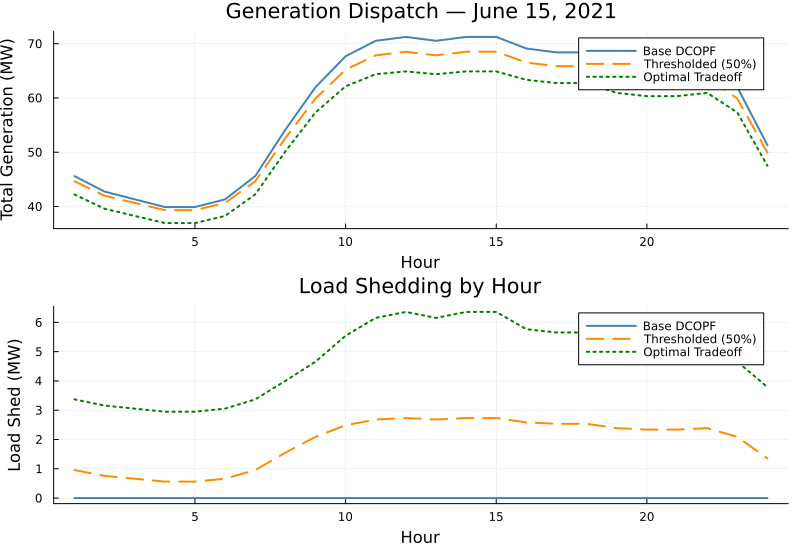

In [7]:
using Plots

# results[:g] has shape [D × T × generators]; sum over generators for each hour
gen_base   = [sum(results_base[:g][1, t, :])   for t in 1:24]
gen_thresh = [sum(results_thresh[:g][1, t, :]) for t in 1:24]
gen_opt    = [sum(results_opt[:g][1, t, :])    for t in 1:24]

# Load shedding by hour
ls_base   = [sum(results_base[:load_shedding][1, t, :])   for t in 1:24]
ls_thresh = [sum(results_thresh[:load_shedding][1, t, :]) for t in 1:24]
ls_opt    = [sum(results_opt[:load_shedding][1, t, :])    for t in 1:24]

p1 = plot(1:24, gen_base,   label="Base DCOPF",        lw=2, color=:steelblue)
plot!(p1, 1:24, gen_thresh, label="Thresholded (50%)", lw=2, color=:darkorange, ls=:dash)
plot!(p1, 1:24, gen_opt,    label="Optimal Tradeoff",  lw=2, color=:green,      ls=:dot)
plot!(p1, xlabel="Hour", ylabel="Total Generation (MW)", title="Generation Dispatch — June 15, 2021",
      legend=:topright, grid=true)

p2 = plot(1:24, ls_base,   label="Base DCOPF",        lw=2, color=:steelblue)
plot!(p2, 1:24, ls_thresh, label="Thresholded (50%)", lw=2, color=:darkorange, ls=:dash)
plot!(p2, 1:24, ls_opt,    label="Optimal Tradeoff",  lw=2, color=:green,      ls=:dot)
plot!(p2, xlabel="Hour", ylabel="Load Shed (MW)", title="Load Shedding by Hour",
      legend=:topright, grid=true)

plot(p1, p2, layout=(2,1), size=(800,550))

### Which Lines Were Switched Off?

The `:switched_off_lines` key maps day index → vector of de-energized line IDs.

In [8]:
println("Lines switched off (Base DCOPF):")
println("  ", results_base[:switched_off_lines][1])

println("\nLines switched off (Thresholded 50%):")
println("  ", results_thresh[:switched_off_lines][1])

println("\nLines switched off (Optimal Tradeoff):")
println("  ", results_opt[:switched_off_lines][1])

# Highlight lines unique to each approach
unique_to_thresh = setdiff(results_thresh[:switched_off_lines][1], results_opt[:switched_off_lines][1])
unique_to_opt    = setdiff(results_opt[:switched_off_lines][1],    results_thresh[:switched_off_lines][1])
println("\nLines only the thresholded method removes: $unique_to_thresh")
println("Lines only the optimal method removes:     $unique_to_opt")

Lines switched off (Base DCOPF):
  Int64[]

Lines switched off (Thresholded 50%):
  [12, 43, 46, 53, 54, 66, 67, 68, 72, 81, 83, 91, 92, 100, 101, 118]

Lines switched off (Optimal Tradeoff):
  [2, 3, 5, 6, 8, 12, 13, 14, 19, 20, 21, 27, 34, 35, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 52, 53, 54, 55, 60, 62, 66, 67, 68, 69, 71, 72, 73, 74, 75, 76, 78, 79, 81, 82, 83, 84, 85, 87, 88, 90, 91, 92, 94, 96, 97, 99, 100, 101, 105, 113, 114, 115, 118, 119, 120]

Lines only the thresholded method removes: Int64[]
Lines only the optimal method removes:     [2, 3, 5, 6, 8, 13, 14, 19, 20, 21, 27, 34, 35, 40, 41, 42, 44, 45, 48, 49, 50, 52, 55, 60, 62, 69, 71, 73, 74, 75, 76, 78, 79, 82, 84, 85, 87, 88, 90, 94, 96, 97, 99, 105, 113, 114, 115, 119, 120]


---
## 4. Infrastructure Investments

GridPlanning can co-optimize operational switching with long-term infrastructure investments:
- **Line hardening**: permanently reduce a line's wildfire risk (vegetation management, covered conductors, undergrounding)
- **Battery energy storage (BESS)**: install storage to shift load and reduce shedding
- **Solar PV**: install distributed generation near load centers

All three share a common `infrastructure_budget` constraint (default: \$1 billion for non-cost objectives).

### 4a. Line Hardening

Hardening permanently reduces a line's risk contribution by `hardening_effectiveness` (default: 100%). The cost model defaults to \$7M/mile, reflecting undergrounding; reduce it to model cheaper interventions.

In [9]:
params_harden = Dict(
    :network                    => "RTS",
    :model                      => "DCOTS",
    :objective                  => "loadshed",
    :times                      => [(2020, 6, 15)],
    :data_dir                   => "test_data",

    # Hardening settings
    :hardening_enabled          => true,
    :hardening_effectiveness    => 1.0,     # 100% risk reduction (undergrounding)
    :hardening_cost_per_mile    => 7e6,     # $7M/mile (undergrounding)
    :infrastructure_budget      => 50e6,    # $50M budget
)

results_harden = solve_ots(params_harden)

println("=== Hardening Results ===")
println("Lines hardened:    $(results_harden[:hardened_lines])")
println("Hardening cost:    \$$(round(results_harden[:hardening_cost]/1e6, digits=2))M")
println("Risk mitigated:    $(round(results_harden[:mitigated_risk], digits=1))")
println("Total load shed:   $(round(results_harden[:total_load_shed], digits=2)) MW")
println("Risk reduction:    $(round(results_harden[:risk_reduction_pct], digits=1))%")


--- Validating Hardening Parameters ---
✓ Hardening parameters validated:
  Effectiveness: 100.0% risk mitigation
  Cost per mile: $7.0M
  Infrastructure budget: $0.05B (shared)
  Enforce energization: true
Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day

--- Preparing Hardening Infrastructure ---
  Determined hardenable lines: 90 lines with wildfire risk

--- Line Length Data Summary ---
✓ Calculated line lengths for 120 lines
  Total network length: 3380.0 miles
  Lines with coordinates: 120 / 120

--- Hardening Budget Analysis ---
  Hardenable lines: 90
  Total hardenable miles: 2892.0
  Max hardening cost: $20.24B
  Budget allows: 0.2% of max hardening
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: loadshed
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set p

### 4b. Battery Energy Storage

Batteries are co-optimized with switching: the solver decides where to install capacity and how to dispatch it each hour. Here we use the `tradeoff` objective so the solver balances load shedding reduction against wildfire risk when deciding how to dispatch storage.

- `1 p.u. = 100 MWh` of storage capacity
- `battery_cost_per_pu = 20e6` → \$20M per 100 MWh

> ⏱️ **Note:** This cell can take up to ~20 minutes to solve. The `tradeoff` objective and battery dispatch variables together make this a larger MIP than the base runs above.

In [10]:
params_batt = Dict(
    :network              => "RTS",
    :model                => "DCOTS",
    :objective            => "tradeoff",
    :tradeoff_weight       => 0.5,       # equal weight on load shed and wildfire risk
    :times                => [(2020, 6, 15)],
    :data_dir             => "test_data",

    # Battery settings
    :battery_enabled      => true,
    :battery_cost_per_pu  => 20e6,       # $20M per 100 MWh
    :infrastructure_budget => 200e6,    # $200M budget
    :battery_candidate_buses => "load buses",  # only consider installing at load buses
)

results_batt = solve_ots(params_batt)

println("=== Battery Results ===")
println("Batteries installed at buses: $(results_batt[:batteries_installed])")
println("Total capacity:  $(round(results_batt[:total_battery_capacity]*100, digits=1)) MWh")
println("Battery cost:    \$$(round(results_batt[:battery_cost]/1e6, digits=2))M")
println("Total load shed: $(round(results_batt[:total_load_shed], digits=2)) MW")
println("(vs. base DCOPF: $(round(results_base[:total_load_shed], digits=2)) MW)")


--- Validating Battery Parameters ---
✓ Battery parameters validated:
  Cost per p.u. (100MWh): $20.0M
  Charge efficiency: 95.0%
  Discharge efficiency: 95.0%
  SOC carryover: 99.9958%
  Charge rate: 1.0 p.u./hour
  Discharge rate: 1.0 p.u./hour
  Exclusive operation: false
  Infrastructure budget: $0.2B (shared)
Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day

--- Preparing Battery Infrastructure ---
  Battery candidates: 51 load buses
✓ Battery candidate buses identified: 51 buses
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: tradeoff
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
✓ Added battery variables for 51 candidate buses
Adding objective function...
Adding c

### 4c. Battery Dispatch Profile

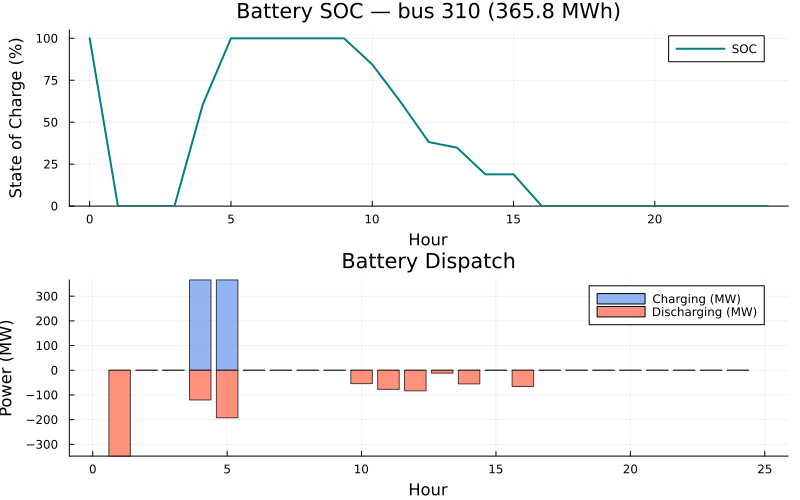

In [24]:
batt_buses = results_batt[:batteries_installed]   # Vector of bus IDs with capacity ≥ 0.01 p.u.

if !isempty(batt_buses)
    # results[:x] is Dict{Int,Float64}: bus_id => capacity (p.u.)
    bus = batt_buses[argmax([results_batt[:x][b] for b in batt_buses])]  # largest installed unit
    cap_pu  = results_batt[:x][bus]
    cap_mwh = round(cap_pu * 100, digits=1)

    # SOC is in p.u. of energy (0 to x[bus]), not a 0-1 fraction — normalise before plotting
    soc_profile       = [results_batt[:soc][(1, t, bus)] / cap_pu * 100  for t in 0:24]
    charge_profile    = [results_batt[:p_charge][(1, t, bus)] * 100      for t in 1:24]
    discharge_profile = [results_batt[:p_discharge][(1, t, bus)] * 100   for t in 1:24]

    p_soc = plot(0:24, soc_profile,
                 label="SOC", lw=2, color=:teal,
                 xlabel="Hour", ylabel="State of Charge (%)",
                 title="Battery SOC — bus $bus ($cap_mwh MWh)",
                 ylims=(0, 105), grid=true)

    p_flow = bar(1:24, charge_profile,
                 label="Charging (MW)", color=:cornflowerblue, alpha=0.7)
    bar!(p_flow, 1:24, .-discharge_profile,
         label="Discharging (MW)", color=:tomato, alpha=0.7,
         xlabel="Hour", ylabel="Power (MW)", title="Battery Dispatch", grid=true)

    plot(p_soc, p_flow, layout=(2,1), size=(800, 500))
else
    println("No batteries installed within the given budget.")
end

### 4d. Combined: Batteries + Solar + Hardening

All three investment types can be enabled simultaneously with a shared budget. The solver allocates spending across them optimally.

In [30]:
params_all = Dict(
    :network              => "RTS",
    :model                => "DCOTS",
    :objective            => "tradeoff",
    :tradeoff_weight       => 0.5,       # equal weight on load shed and wildfire risk
    :times                => [(2020, 6, 15)],
    :data_dir             => "test_data",

    # Shared budget for all infrastructure
    :infrastructure_budget => 300e6,   # $300M total

    # Hardening
    :hardening_enabled     => true,
    :hardening_cost_per_mile => 7e6,
    :hardening_effectiveness => 1.0,

    # Batteries
    :battery_enabled       => true,
    :battery_cost_per_pu   => 20e6,
    :battery_candidate_buses => "load buses",

    # Solar
    :solar_enabled         => true,
    :solar_cost_per_pu     => 20e6,
)

results_all = solve_ots(params_all)

println("=== Combined Infrastructure ===")
println("Total load shed: $(round(results_all[:total_load_shed], digits=2)) MW")
println("Risk reduction:  $(round(results_all[:risk_reduction_pct], digits=1))%")

if haskey(results_all, :hardened_lines) && !isempty(results_all[:hardened_lines])
    println("Lines hardened:  $(results_all[:hardened_lines])  (\$$(round(results_all[:hardening_cost]/1e6, digits=1))M)")
end
if haskey(results_all, :batteries_installed) && !isempty(results_all[:batteries_installed])
    println("Batteries:       $(round(results_all[:total_battery_capacity]*100, digits=1)) MWh  (\$$(round(results_all[:battery_cost]/1e6, digits=1))M)")
end
if haskey(results_all, :solar_installed) && !isempty(results_all[:solar_installed])
    println("Solar:           $(round(results_all[:total_solar_capacity]*100, digits=1)) MW   (\$$(round(results_all[:solar_cost]/1e6, digits=1))M)")
end


--- Validating Hardening Parameters ---
✓ Hardening parameters validated:
  Effectiveness: 100.0% risk mitigation
  Cost per mile: $7.0M
  Infrastructure budget: $0.3B (shared)
  Enforce energization: true

--- Validating Battery Parameters ---
✓ Battery parameters validated:
  Cost per p.u. (100MWh): $20.0M
  Charge efficiency: 95.0%
  Discharge efficiency: 95.0%
  SOC carryover: 99.9958%
  Charge rate: 1.0 p.u./hour
  Discharge rate: 1.0 p.u./hour
  Exclusive operation: false
  Infrastructure budget: $0.3B (shared)

--- Validating Solar Parameters ---
✓ Solar parameters validated:
  Cost per p.u. (100MW): $20.0M
  Default capacity factor: 0.3
  Data path: none (using flat default capacity factor)
Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day

--- Preparing Hardening Infrastructure ---
  Determined hardenable lines: 90 lines with wildfire risk

--- Line Length Data Summary ---
✓ Calculated line lengths for 120 lines
  T

### 4e. Built-in Plots

`plot_results()` generates publication-quality figures from any results dictionary.

**Available features:**

| Symbol | Description |
|--------|-------------|
| `:network_overview` | Geographic map — branches colored by risk, buses sized by load shed, infrastructure overlaid |
| `:load_shed_timeseries` | Hourly load shedding heatmap across buses |
| `:generation_dispatch` | Stacked generation dispatch by type |
| `:battery_dispatch` | Battery SOC and charge/discharge profiles |
| `:solar_generation` | Solar output vs. capacity factor by bus |
| `:cost_breakdown` | Infrastructure cost breakdown by type |
| `:tradeoff_curve` | Pareto front across tradeoff weights (requires Vector{Dict} input) |

In [31]:
mkpath("tutorial_plots")

features = [:network_overview, :load_shed_timeseries, :generation_dispatch]
if haskey(results_all, :batteries_installed) && !isempty(results_all[:batteries_installed])
    push!(features, :battery_dispatch)
end
if haskey(results_all, :solar_installed) && !isempty(results_all[:solar_installed])
    push!(features, :solar_generation)
end

plot_results(results_all, features; format="png", output_dir="tutorial_plots")

println("Plots saved to tutorial_plots/:")
for f in readdir("tutorial_plots")
    println("  $f")
end

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
✓ Saved: tutorial_plots/network_overview_RTS_2020-06-15.png
✓ Saved: tutorial_plots/load_shed_timeseries_RTS_2020-06-15.png
✓ Saved: tutorial_plots/generation_dispatch_RTS_2020-06-15.png
✓ Saved: tutorial_plots/solar_generation_RTS_2020-06-15.png
Plots saved to tutorial_plots/:
  autoplots
  generation_dispatch_RTS_2020-06-15.png
  load_shed_timeseries_RTS_2020-06-15.png
  network_overview_RTS_2020-06-15.png
  solar_generation_RTS_2020-06-15.png
  tradeoff_curve.png


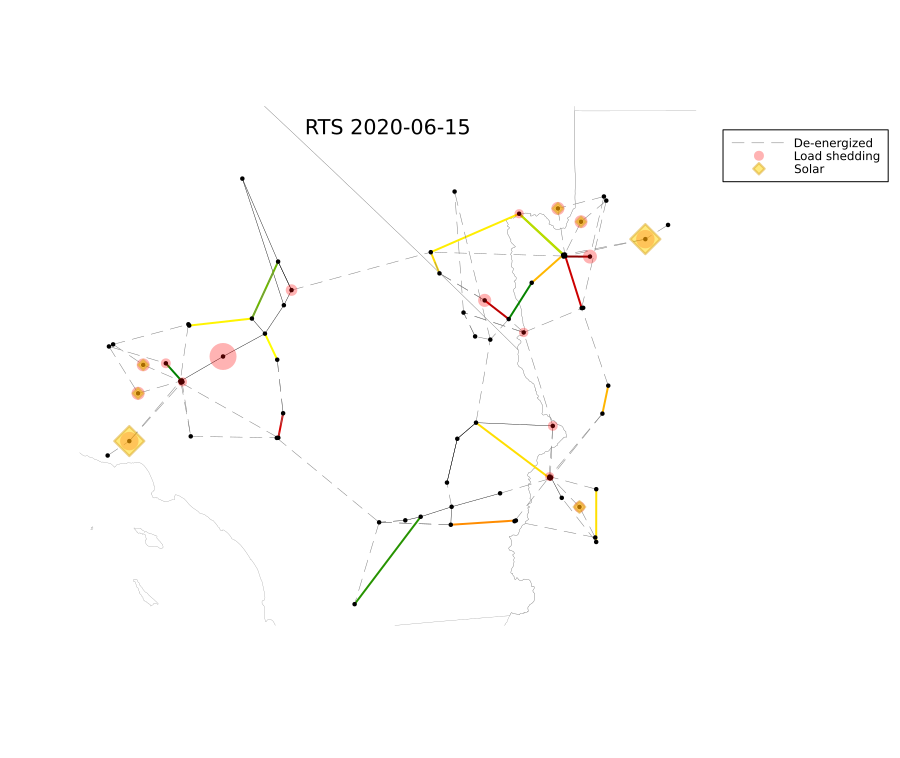

In [32]:
# Display the network overview inline
overview_files = filter(f -> startswith(f, "network_overview"), readdir("tutorial_plots"))
if !isempty(overview_files)
    display("image/png", read(joinpath("tutorial_plots", overview_files[1])))
end

### 4f. Tradeoff Curve

To visualize the Pareto front between load shedding and wildfire risk, run the `tradeoff` objective at several weights and pass the resulting list of dicts to `plot_results`.

In [34]:
weights = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
tradeoff_results = Dict[]

for w in weights
    r = solve_ots(Dict(
        :network         => "RTS",
        :model           => "DCOTS",
        :objective       => "tradeoff",
        :tradeoff_weight => w,
        :times           => [(2020, 6, 15)],
        :data_dir        => "test_data",
    ))
    push!(tradeoff_results, r)
    println(@sprintf("w=%.1f → load shed: %.1f MW, risk reduction: %.1f%%",
        w, r[:total_load_shed], r[:risk_reduction_pct]))
end

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: tradeoff
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  86400
MIPGap  0.01
Seed  1

Optimize a model with 16896 rows, 8778 columns and 53760 non

✓ Saved: tutorial_plots/tradeoff_curve.png


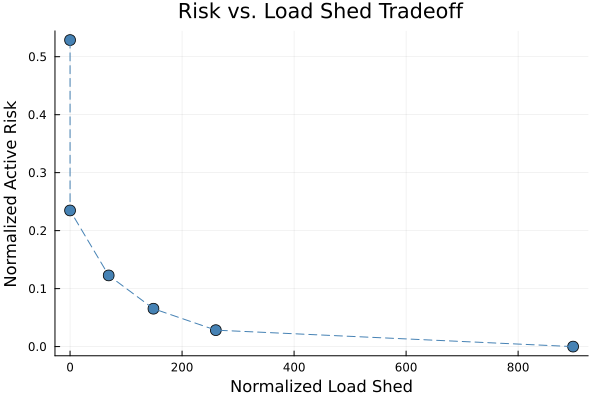

In [35]:
# Built-in tradeoff curve plot
plot_results(tradeoff_results, [:tradeoff_curve];
             format="png", output_dir="tutorial_plots")

tradeoff_path = joinpath("tutorial_plots",
    filter(f -> startswith(f, "tradeoff_curve"), readdir("tutorial_plots"))[1])
display("image/png", read(tradeoff_path))

---
## 5. Parameters and Customization

### 5a. Objective Functions

| `:objective` | Minimizes | Best for |
|---|---|---|
| `"loadshed"` | Total load shed (MW) | Reliability studies |
| `"wildfire"` | Normalized active wildfire risk | Wildfire safety focus |
| `"cost"` | Generation cost + VOLL × load shed | Economic dispatch |
| `"tradeoff"` | `(1-w) × norm_loadshed + w × norm_risk` | Balanced studies |

In [36]:
# Cost objective — uses generator marginal costs and Value of Lost Load (VOLL)
params_cost = Dict(
    :network   => "RTS",
    :model     => "DCOTS",
    :objective => "cost",
    :voll      => 10000.0,   # $/MWh value of lost load
    :times     => [(2020, 6, 15)],
    :data_dir  => "test_data",
)

results_cost = solve_ots(params_cost)
println("Cost objective → load shed: $(round(results_cost[:total_load_shed], digits=2)) MW, ",
        "risk reduction: $(round(results_cost[:risk_reduction_pct], digits=1))%")

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: cost
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  86400
MIPGap  0.01
Seed  1

Optimize a model with 16896 rows, 8778 columns and 53760 nonzero

### 5b. Multi-Day Studies

Solve multiple days in a single call. Results arrays have shape `[D × T × ...]`.

In [37]:
# Three consecutive days from the reference dataset
params_multiday = Dict(
    :network   => "RTS",
    :model     => "DCOTS",
    :objective => "loadshed",
    :times     => [(2020, 6, 10), (2020, 6, 11), (2020, 6, 12)],
    :data_dir  => "test_data",
)

results_multi = solve_ots(params_multiday)

println("Multi-day results (D=$(results_multi[:D]) days):")
for d in 1:results_multi[:D]
    ls_d = sum(results_multi[:load_shedding][d, :, :])
    println("  Day $d: $(round(ls_d, digits=2)) MW shed, lines off: $(results_multi[:switched_off_lines][d])")
end

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 3 days, max 90 risky lines per day
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: loadshed
Days: 3, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Set parameter MIPFocus to value 2
Set parameter Method to value 2
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter Method to value 2
Set parameter MIPGap to value 0.01
Set parameter MIPFocus to value 2
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 

### 5c. Solver Settings

In [38]:
# Tighter optimality gap and longer time limit
params_tight = Dict(
    :network    => "RTS",
    :model      => "DCOTS",
    :objective  => "tradeoff",
    :tradeoff_weight => 0.5,
    :times      => [(2020, 6, 15)],
    :data_dir   => "test_data",
    :mip_gap    => 0.001,     # 0.1% gap (default is 1%)
    :time_limit => 300.0,     # 5 minute cap
)

results_tight = solve_ots(params_tight)
println("Tight MIP: status=$(results_tight[:status]), time=$(round(results_tight[:solve_time], digits=2))s")

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: tradeoff
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.001
Set parameter TimeLimit to value 300
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.001
Set parameter TimeLimit to value 300
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.001
Seed  1

Optimize a model with 16896 rows, 8778 columns and 53760 nonzer

### 5d. Saving and Loading Results

In [20]:
# Save to JLD2 (binary, preserves full arrays)
params_save = merge(params_base, Dict(
    :output_format => "jld2",
    :output_path   => "tutorial_output/rts_base.jld2",
))
mkpath("tutorial_output")
_ = solve_ots(params_save)
println("Saved to tutorial_output/rts_base.jld2")

# Load back in a later session:
# using JLD2
# results_loaded = load("tutorial_output/rts_base.jld2", "results")

# Or use the package helper for .txt files:
# results_loaded = load_txt("tutorial_output/rts_base.txt")

✓ risk_per_line validation passed:
  - 1 days of data
  - 90 total line-day risk entries
  - Min/Max risky lines per day: 90/90
✓ Using user-provided wildfire_data (legacy parameter)
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: loadshed
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  86400
MIPGap  0.

### 5e. LACOTS (Linearized AC Model)

LACOTS adds reactive power and voltage magnitude variables for a more accurate AC representation. It's slower but is necessary for voltage-constrained studies.

> **Tip:** Use `warm_start: "auto"` to automatically run DCOTS first and initialize LACOTS from that solution — significantly speeds up convergence.

In [39]:
params_lac = Dict(
    :network      => "RTS",
    :model        => "LACOTS",
    :objective    => "loadshed",
    :times        => [(2020, 6, 15)],
    :data_dir     => "test_data",
    :warm_start   => "auto",      # run DCOTS first, use as warm start
    :mip_gap      => 0.01,
    :time_limit   => 120.0,
)

results_lac = solve_ots(params_lac)

println("=== LACOTS Results ===")
println("Status:           $(results_lac[:status])")
println("Solve time:       $(round(results_lac[:solve_time], digits=2)) s")
println("Total load shed:  $(round(results_lac[:total_load_shed], digits=2)) MW")
println("Risk reduction:   $(round(results_lac[:risk_reduction_pct], digits=1))%")
println("Voltage range:    [$(round(minimum(results_lac[:vm]), digits=3)), $(round(maximum(results_lac[:vm]), digits=3))] p.u.")

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
Running DCOTS first for warm start...
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: loadshed
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 120
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 120
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  120
MIPGap  0.01
Seed  1

Optimize a model with 16896 

### 5f. Custom Wildfire Risk Data

Supply your own line-level risk values instead of using the built-in USGS FPI data. The format is a nested dictionary: `day_index => Dict(line_id => risk_value)`.

In [40]:
# Load the built-in risk data from the CSV, then apply a custom scaling
using CSV, DataFrames

rts_csv = CSV.read("test_data/USGS_FPI/RTS/2020_risk.csv", DataFrame)
day_df  = filter(row -> string(row.date_of_forecast) == "2020-06-15", rts_csv)

# Build a Dict{Int,Float64}: line_id => risk
base_risk = Dict{Int,Float64}(row.branch_id => row.cum_wfpi for row in eachrow(day_df))

# Scale all risks by 2× as a hypothetical extreme scenario
custom_risk = Dict(1 => Dict{Int,Float64}(k => 2.0*v for (k,v) in base_risk))

params_custom = Dict(
    :network         => "RTS",
    :model           => "DCOTS",
    :objective       => "tradeoff",
    :tradeoff_weight => 0.5,
    :times           => [(2020, 6, 15)],
    :data_dir        => "test_data",
    :risk_per_line   => custom_risk,    # override auto-loaded data
)

results_custom = solve_ots(params_custom)
println("Custom risk (2×): load shed=$(round(results_custom[:total_load_shed], digits=2)) MW, ",
        "risk reduction=$(round(results_custom[:risk_reduction_pct], digits=1))%")

✓ risk_per_line validation passed:
  - 1 days of data
  - 120 total line-day risk entries
  - Min/Max risky lines per day: 120/120
✓ Using user-provided risk_per_line data
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: tradeoff
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  86400
MIPGap  0.01
Seed  1


### 5g. Auto-Plotting During Solve

Set `:plots` in the parameter dictionary to generate plots automatically at the end of `solve_ots()`, without a separate `plot_results()` call.

In [41]:
params_autoplots = Dict(
    :network          => "RTS",
    :model            => "DCOTS",
    :objective        => "loadshed",
    :times            => [(2020, 6, 15)],
    :data_dir         => "test_data",

    # Auto-plot options:
    #   "all"              → network_overview + timeseries
    #   "inv_only"         → network_overview only
    #   "timeseries_only"  → load shed timeseries only
    :plots    => "all",
    :plot_dir => "tutorial_plots/autoplots",
)

_ = solve_ots(params_autoplots)

println("Auto-generated plots:")
for f in readdir("tutorial_plots/autoplots")
    println("  $f")
end

Loading RTS wildfire data from CSV...
Loaded RTS wildfire data from CSV for 1 days, max 90 risky lines per day
Building DCOTS model...
Switching method: optimal
Network: RTS
Objective: loadshed
Days: 1, Hours per day: 24
Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-20
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Adding variables...
Adding objective function...
Adding constraints...
Solving optimization...
Set parameter Seed to value 1
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 86400
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  86400
MIPGap  0.01
Seed  1

Optimize a model with 16896 rows, 8778 columns and 53760 non

---
## Summary

You've covered the full GridPlanning.jl workflow:

| Step | What you did |
|------|--------------|
| **Setup** | Loaded the package and explored the reference dataset |
| **Base DCOPF** | Minimized load shedding with optimal line switching |
| **Thresholded** | Used the fast heuristic to pre-de-energize risky lines |
| **Optimal tradeoff** | Jointly minimized load shed and wildfire risk |
| **Hardening** | Co-optimized permanent line hardening with operations |
| **Batteries** | Installed and dispatched storage to reduce load shed |
| **All-in** | Combined batteries + solar + hardening with a shared budget |
| **Plots** | Used `plot_results()` for geographic and timeseries figures |
| **Customization** | Tuned solver settings, used custom risk data, ran LACOTS |

**Next steps:**
- Try the **tradeoff curve** across a full month: `:times => "June 2021"`
- Scale up to a larger network: change `:network => "WECC240"` or `"Texas2k"`
- Download additional wildfire risk data to study other time periods
- Export results with `:output_format => "jld2"` for downstream analysis

See the [README](README.md) for the complete parameter reference and additional examples.